In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path
import os

from torch.utils.tensorboard import SummaryWriter

import albumentations as A
from albumentations.pytorch import ToTensorV2


/home/jorge/miniconda3/envs/image-recon-dl-env/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# Semilla para reproducibilidad de los experimentos
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [3]:
# Me aseguro de que el directorio raíz del proyecto esté en el sys.path
project_root = Path(os.path.abspath("")).parent

# Añado el directorio raíz al sys.path si no está ya presente
if project_root not in sys.path:
    sys.path.append(str(project_root))

In [4]:
# Importo las funciones de configuración
from src.config import processed_data_dir, models_dir, reports_dir, load_config

from src.utils.datasets import CustomDataset_2_2

from src.models.convolutional_autoencoder_model.model import ConvolutionalAutoencoder
from src.models.convolutional_autoencoder_model.train_model import train_model


Current working directory: /home/jorge/development/WasteImageReconstructionDL/notebooks
Loading configuration from /home/jorge/development/WasteImageReconstructionDL/src/config.yaml


In [5]:
# Cargo la configuración 
config = load_config()

Loading configuration from /home/jorge/development/WasteImageReconstructionDL/src/config.yaml


In [6]:
# Transformación de las imágenes
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Asegurar que las imágenes tengan el mismo tamaño
    transforms.ToTensor(),
])

In [7]:
# Definir el pipeline de augmentación
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.OneOf([
        A.Rotate(limit=(0, 0), p=0.33),
        A.Rotate(limit=(180, 180), p=0.33),
        A.Compose([A.Rotate(limit=(180, 180), p=1.0), A.HorizontalFlip(p=1.0)], p=0.34)
    ], p=1.0)
])

In [8]:
# Ruta de los datos
final_data_dir = processed_data_dir() 

In [9]:
# Definir la ruta de los archivos CSV
train_csv = os.path.join(final_data_dir, 'train.csv')
val_csv = os.path.join(final_data_dir, 'val.csv')

In [10]:
# Crear el dataset
train_dataset = CustomDataset_2_2(
    csv_file=os.path.join(final_data_dir, 'train.csv'),
    transform=transform,
    augmentation_pipeline=augmentation_pipeline,
    use_augmentation=True  # Activar Data Augmentation para el entrenamiento y probar con imágenes aumentadas
)

val_dataset = CustomDataset_2_2(
    csv_file=os.path.join(final_data_dir, 'val.csv'),
    transform=transform,
    use_augmentation=False  # No activar Data Augmentation para el conjunto de validación
)

In [11]:
# Si tenemos disponible GPU, lo usamos
# Chequeamos si tenemos disponible GPU (CUDA)
if torch.cuda.is_available():
    device = "cuda"
# Chequeamos si tenemos disponible aceleración por hardware en un chip de Apple (MPS)
elif torch.backends.mps.is_available():
    device = "mps"
# Por defecto usamos CPU
else:
    device = "cpu"

In [12]:
# Defino los mejores hiperparámetros encontrados
batch_size = 8
#batch_size = 4
encoder_filters = [64, 128, 256, 512, 1024, 2048]
#decoder_filters = list(reversed(encoder_filters))
decoder_filters = [2048, 1024, 512, 256, 128, 64]
#lr = 2.5068459541351344e-05
#lr = 0.00014811589278966822
lr = 8.149533585849922e-05
#lr = 0.0001
#weight_decay = 1.8233727862708232e-05
weight_decay = 1.4647971325326473e-05

In [13]:
# Crear los dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [14]:
model = ConvolutionalAutoencoder(encoder_filters, decoder_filters).to(device)

In [15]:
# Definir el criterio y el optimizador
criterion = nn.MSELoss()
#optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
#optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

In [16]:
nombre_modelo = 'cae_model_best_hyperparameters_8'
output_model_path = models_dir() / "trained"
os.makedirs(output_model_path, exist_ok=True)

In [17]:
# Defino directorio base de logs para tensorboard
log_base_dir = reports_dir()/'logs'
os.makedirs(log_base_dir, exist_ok=True)

In [18]:
# Defino subdirectorio de logs para este modelo
log_dir = log_base_dir / nombre_modelo
os.makedirs(log_dir, exist_ok=True)

In [19]:
# Definir el número de épocas y la mejor pérdida de validación
num_epochs = 200
early_stop_patience = 10


In [20]:
print(log_dir)

/home/jorge/development/WasteImageReconstructionDL/reports/logs/cae_model_best_hyperparameters_8


In [21]:
# Inicializar tensorboard
writer = SummaryWriter(log_dir=str(log_dir), comment="Run_cae_model_best_hyperparameters_8")

In [22]:
%load_ext tensorboard

#%tensorboard --logdir=../reports/logs/convolutional_autoencoder_model_final --host 0.0.0.0 --port 6006
#%tensorboard --logdir=../reports/logs/cae_model_best_hyperparameters --host 0.0.0.0 --port 6006
%tensorboard --logdir=../reports/logs --host 0.0.0.0 --port 6006

In [23]:
# Entrenamiento del modelo
# train_losses, val_losses, val_psnr_values, val_ssim_values, compression_ratios = train_model(
#     model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, writer, output_model_path, nombre_modelo, early_stop_patience
# )

# Entrenamiento del modelo
train_losses, val_losses, val_psnr_values, val_ssim_values, compression_ratios = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, writer, output_model_path, nombre_modelo, early_stop_patience
)

Epoch [1/200], Train Loss: 0.0457, Val Loss: 0.0397, Val PSNR: 10.8321, Val SSIM: 0.2069, Compression Ratio: 6.00
Epoch [2/200], Train Loss: 0.0231, Val Loss: 0.0176, Val PSNR: 15.5178, Val SSIM: 0.2294, Compression Ratio: 6.00
Epoch [3/200], Train Loss: 0.0162, Val Loss: 0.0153, Val PSNR: 16.4720, Val SSIM: 0.2299, Compression Ratio: 6.00
Epoch [4/200], Train Loss: 0.0142, Val Loss: 0.0137, Val PSNR: 17.3351, Val SSIM: 0.2459, Compression Ratio: 6.00
Epoch [5/200], Train Loss: 0.0137, Val Loss: 0.0149, Val PSNR: 16.5041, Val SSIM: 0.2465, Compression Ratio: 6.00
Epoch [6/200], Train Loss: 0.0126, Val Loss: 0.0124, Val PSNR: 17.9493, Val SSIM: 0.2546, Compression Ratio: 6.00
Epoch [7/200], Train Loss: 0.0122, Val Loss: 0.0131, Val PSNR: 17.7104, Val SSIM: 0.2596, Compression Ratio: 6.00
Epoch [8/200], Train Loss: 0.0118, Val Loss: 0.0118, Val PSNR: 18.2384, Val SSIM: 0.2589, Compression Ratio: 6.00
Epoch [9/200], Train Loss: 0.0114, Val Loss: 0.0123, Val PSNR: 17.7247, Val SSIM: 0.2630

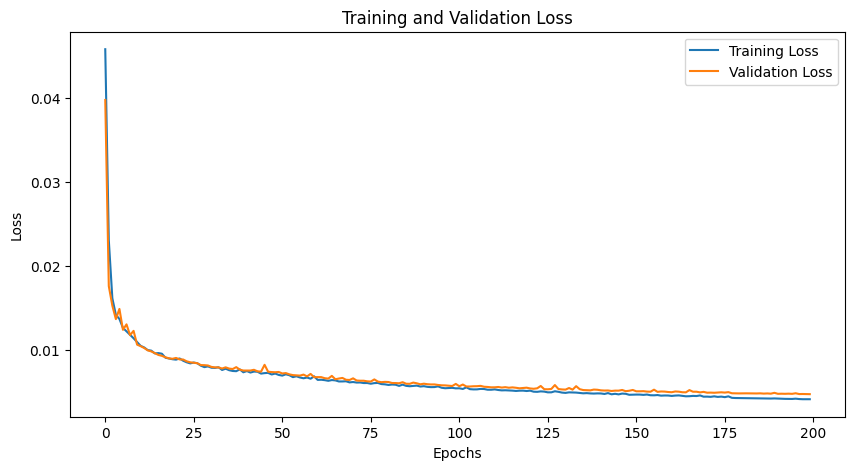

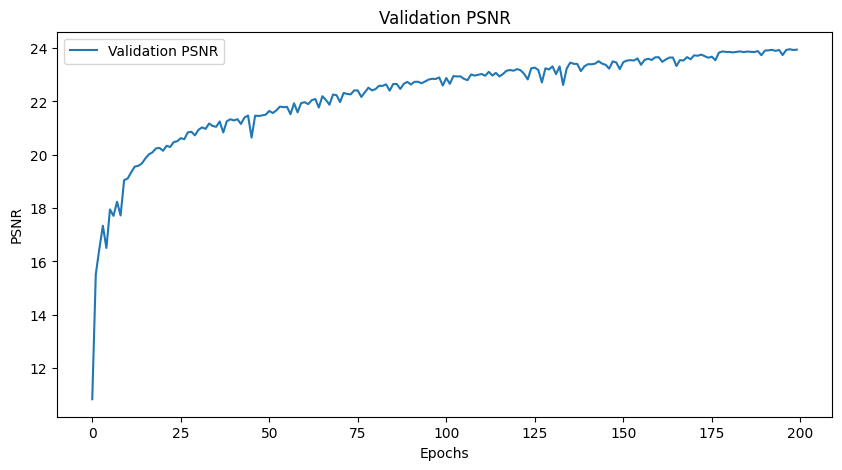

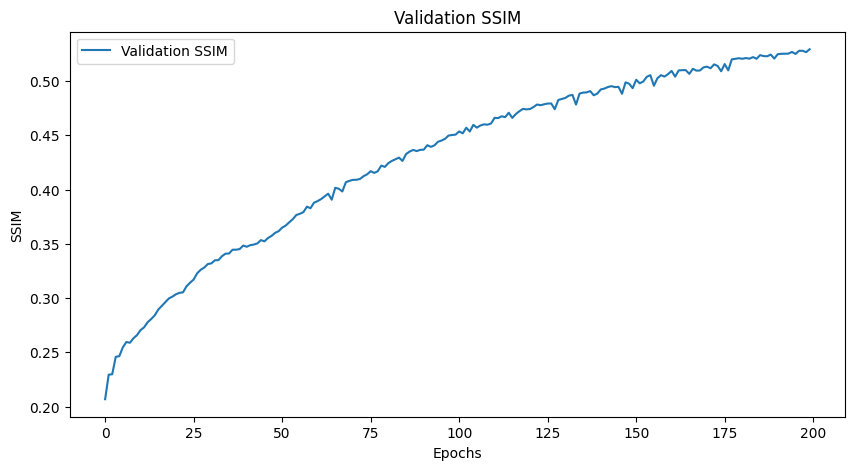

In [24]:
# Graficar las pérdidas de entrenamiento y validación
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

# Graficar PSNR y SSIM de validación
plt.figure(figsize=(10, 5))
plt.plot(val_psnr_values, label='Validation PSNR')
plt.xlabel('Epochs')
plt.ylabel('PSNR')
plt.legend()
plt.title('Validation PSNR')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(val_ssim_values, label='Validation SSIM')
plt.xlabel('Epochs')
plt.ylabel('SSIM')
plt.legend()
plt.title('Validation SSIM')
plt.show()